In [216]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Two-Mirror Concentrator

In [217]:
flat_source, flat_target, inv, hl, f1, L, f2, da, a_max, w = np.loadtxt('data2mc/input.csv', delimiter = ',')
mirror1a = np.loadtxt('data2mc/mirror1a.csv', delimiter = ',')
mirror1b = np.loadtxt('data2mc/mirror1b.csv', delimiter = ',')
mirror2a = np.loadtxt('data2mc/mirror2a.csv', delimiter = ',')
mirror2b = np.loadtxt('data2mc/mirror2b.csv', delimiter = ',')

In [218]:
source_text = "flat" if flat_source else "cylindrical"
target_text = "flat" if flat_target else "cylindrical"
inverted_text = "inverted" if inv else "not inverted"
print(f"{source_text} source -> {target_text} target, {inverted_text}")
print(f"half-length = {hl}, f1 = {f1}, L = {L}, f2 = {f2}, da = {da}, a_max = {a_max}, w = {w}")

cylindrical source -> cylindrical target, not inverted
half-length = 0.001, f1 = 1.0, L = 30.0, f2 = 1.0, da = 0.0001, a_max = 150.0, w = 1.0


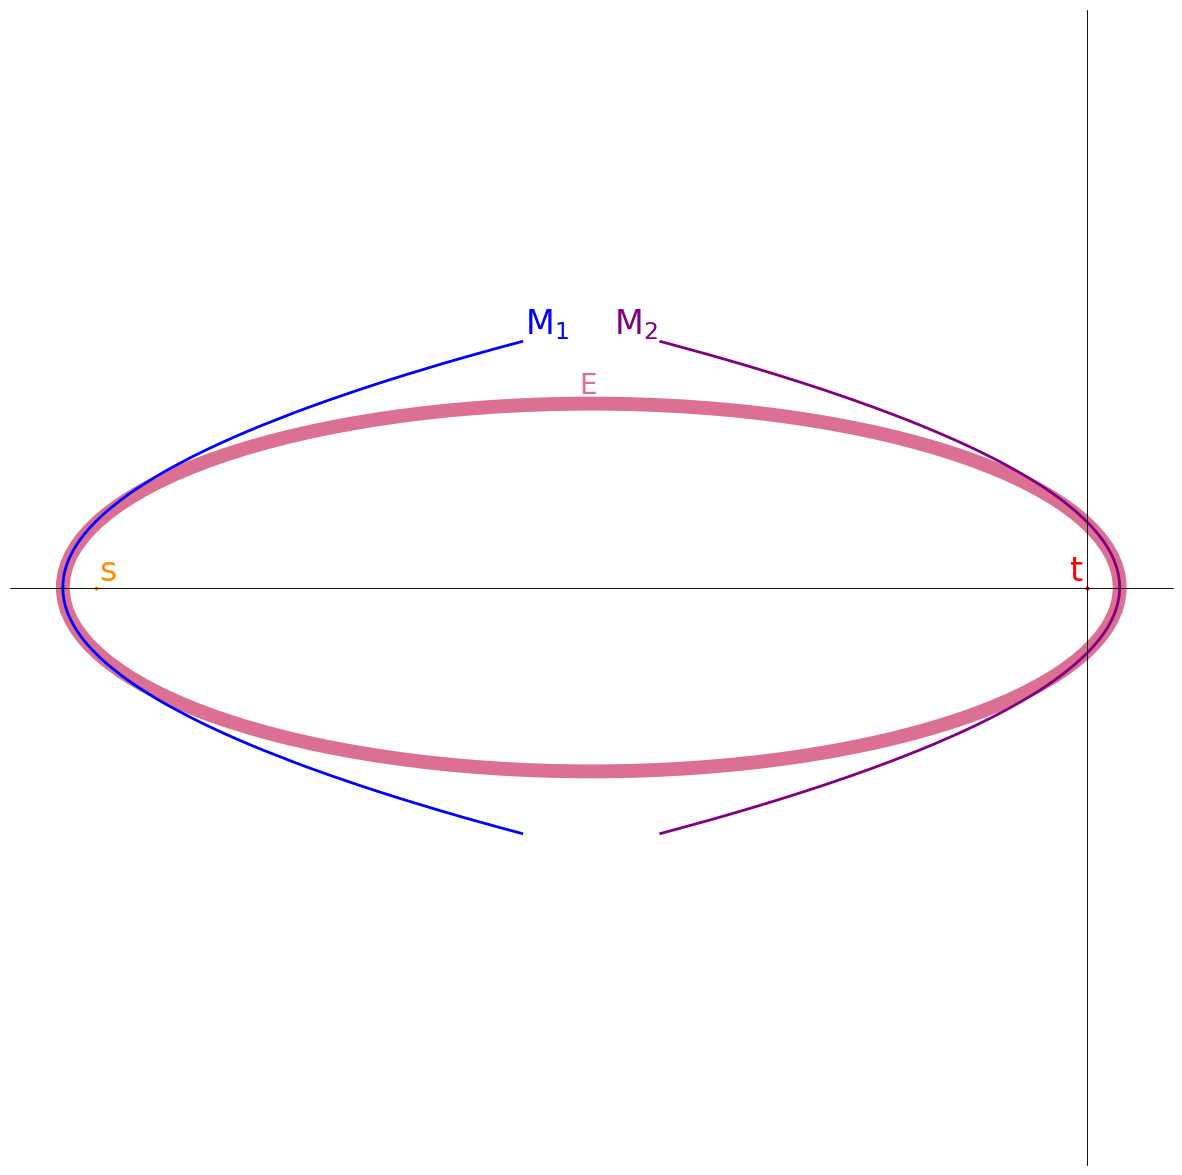

In [225]:
# setup
fig, ax = plt.subplots(1, figsize = (15, 15))
ax.spines['left'].set_position('zero')
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_position('zero')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['right'].set_position('zero')
ax.spines['right'].set_linewidth(0.5)
ax.spines['top'].set_position('zero')
ax.spines['top'].set_linewidth(0.5)
ax.set_xticks([])
ax.set_yticks([])

# rays
# finalplotrays = np.loadtxt('datafin/finalplotrays.csv', delimiter = ',')
# for row in finalplotrays: plt.plot([row[0], row[2]], [row[1], row[3]], linestyle = 'dashed', dashes = [20, 10], linewidth = 0.2, c = 'black')
# diffuse = np.loadtxt('datafin/diffuse.csv', delimiter = ',')
# for row in diffuse: plt.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.2, c = 'green')

# label adjustment
adj = 0.1

# ellipse
plt.gca().add_patch(matplotlib.patches.Ellipse(xy = (-L / 2, 0), width = 2 * f1 + L, height = 2 * np.sqrt(f1 * (f1 + L)), edgecolor = 'palevioletred', facecolor = 'none', fill = False, lw = 10))
ax.text(-L / 2 - adj, np.sqrt(f1 * (f1 + L)) + adj, ha = 'center', va = 'bottom', s = r"$\text{E}$", fontsize = 20, color = 'palevioletred')

# parabolas
# Y1 = np.linspace(-2 * f1, 2 * f1, 100)
# X1 = 1 / (4 * f1) * (Y1 ** 2) - L - f1
# ax.plot(X1, Y1, linewidth = 10, c = 'lightsteelblue')
# ax.text(X1[-1] + adj, Y1[1], ha = 'left', va = 'bottom', s = r"$\text{P}_1$", fontsize = 24, color = 'lightsteelblue')
# Y2 = np.linspace(-2 * f2, 2 * f2, 100)
# X2 = -1 / (4 * f2) * (Y2 ** 2) + f2
# ax.plot(X2, Y2, linewidth = 10, c = 'thistle')
# ax.text(X2[-1] - adj, Y2[1], ha = 'right', va = 'bottom', s = r"$\text{P}_2$", fontsize = 24, color = 'thistle')

# mirrors
ax.plot(mirror1a[:, 0], mirror1a[:, 1], linewidth = 2, c = 'blue', label = r"$\text{M}_1$")
ax.plot(mirror1b[:, 0], mirror1b[:, 1], linewidth = 2, c = 'blue')
ax.text(mirror1a[-1, 0] + adj, mirror1a[-1, 1], ha = 'left', va = 'bottom', s = r"$\text{M}_1$", fontsize = 24, color = 'blue')
ax.plot(mirror2a[:, 0], mirror2a[:, 1], linewidth = 2, c = 'purple', label = r"$\text{M}_2$")
ax.plot(mirror2b[:, 0], mirror2b[:, 1], linewidth = 2, c = 'purple')
ax.text(mirror2a[-1, 0] - adj, mirror2a[-1, 1], ha = 'right', va = 'bottom', s = r"$\text{M}_2$", fontsize = 24, color = 'purple')

# source
if flat_source: plt.plot([-L, -L], [-hl, hl], linewidth = 4, color = 'darkorange', label = 'source')
# else: plt.gca().add_patch(plt.Circle((-L, 0), hl, color = 'darkorange', label = 'source'))
else: plt.scatter(-L, 0, s = 4, c = 'darkorange')
# plt.annotate(r"$\text{s}$", xy = (-L, 0), xytext = ((mirror1a[0, 0] + L) * 1.25 - L, mirror1a[-1, 1] / 2), color = 'darkorange',
#              arrowprops = dict(arrowstyle = '-', linestyle = 'dashed', linewidth = 0.5, color = 'darkorange', shrinkA = 5, shrinkB = 10),
#              horizontalalignment = 'center')
ax.text(-L + adj, 0, ha = 'left', va = 'bottom', s = r"$\text{s}$", fontsize = 24, color = 'darkorange')

# target
if flat_target:
	if flat_source: plt.plot([0, 0], [-hl * w, hl * w], linewidth = 4, color = 'red', label = 'target')
	else: plt.plot([0, 0], [-hl * np.pi * w, hl * np.pi * w], linewidth = 4, color = 'red', label = 'target')
else:
	# if flat_source: plt.gca().add_patch(plt.Circle((0, 0), hl / np.pi * w, color = 'red', label = 'target'))
	# else: plt.gca().add_patch(plt.Circle((0, 0), hl * w, color = 'red', label = 'target'))
	plt.scatter(0, 0, s = 4, c = 'red')
# plt.annotate(r"$\text{t}$", xy = (0, 0), xytext = (mirror2a[0, 0] * 1.25, mirror2a[-1, 1] / 2), color = 'red',
#              arrowprops = dict(arrowstyle = '-', linestyle = 'dashed', linewidth = 0.5, color = 'red', shrinkA = 5, shrinkB = 10),
#              horizontalalignment = 'center')
ax.text(0 - adj, 0, ha = 'right', va = 'bottom', s = r"$\text{t}$", fontsize = 24, color = 'red')

# plot
plt.axis('equal')
plt.show()

# Extreme Rays

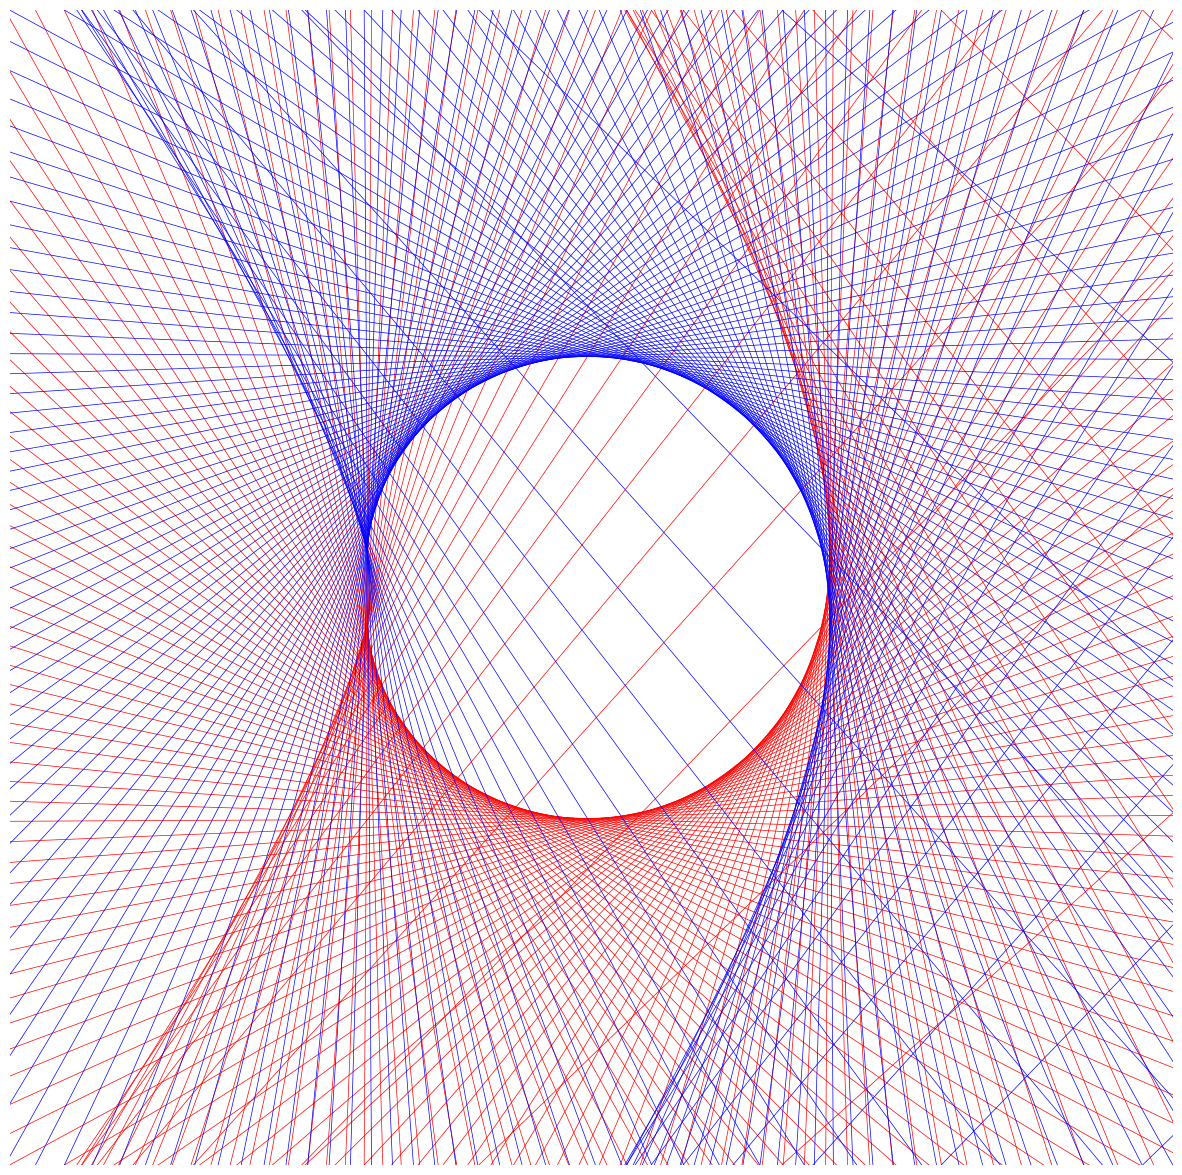

In [220]:
fig, ax = plt.subplots(1, figsize = (15, 15))
extreme1 = np.loadtxt('data2mc/extreme1.csv', delimiter = ',')
extreme2 = np.loadtxt('data2mc/extreme2.csv', delimiter = ',')
for row in extreme1: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.5, c = 'red')
for row in extreme2: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.5, c = 'blue')
if flat_source and flat_target: plt.plot([0, 0], [-hl, hl], linewidth = 4, color = 'black', label = 'target')
elif not flat_source and flat_target: plt.plot([0, 0], [-hl, hl], linewidth = 4, color = 'black', label = 'target')
plt.axis('equal')
zoom = hl * 2.5
plt.axis([-zoom, zoom, -zoom, zoom])
plt.axis('off')
plt.show()

# Phase Space

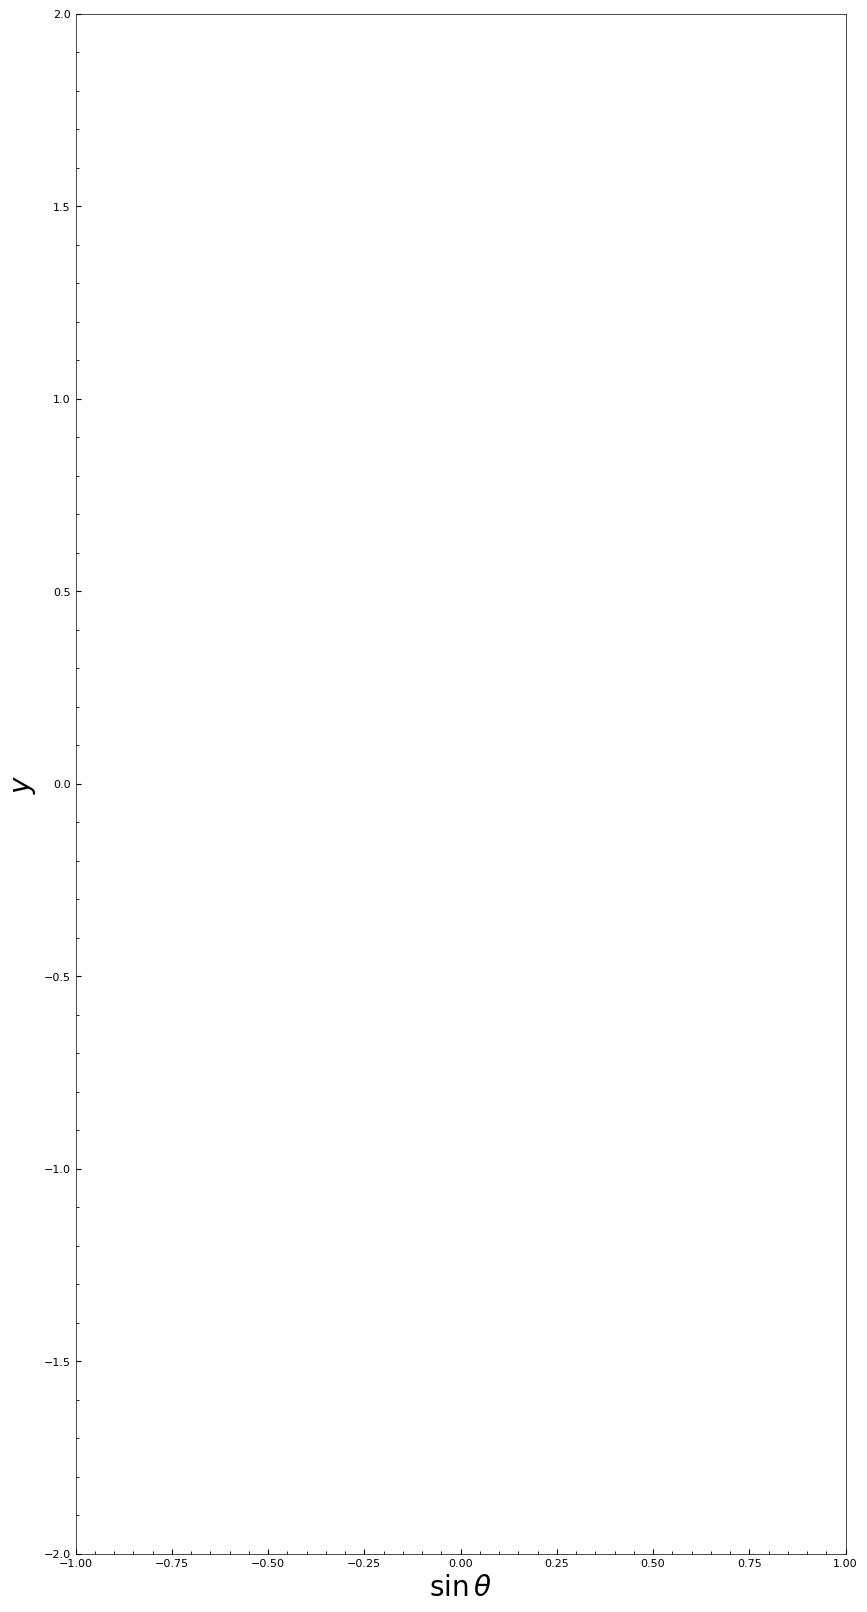

In [221]:
# flat target
phase_target = np.loadtxt('data2mc/phase.csv', delimiter = ',')
fig, ax = plt.subplots(1, figsize = (10, 20))
ax.scatter(phase_target[:, 0], phase_target[:, 1] / hl, s = 0.1, c = 'cornflowerblue')

ax.minorticks_on() 
ax.tick_params(axis = 'x', which = 'both', direction = 'in', bottom = True, top = False, labelsize = 8)
ax.tick_params(axis = 'y', which = 'both', direction = 'in', left = True, right = False, labelsize = 8)

vert = 2
# ax.scatter([0, 0], [-vert, vert + 2], c = 'white')
ax.spines['left'].set_position(('data', -1))
ax.spines['left'].set_bounds((-vert, vert))
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_position(('data', -vert))
ax.spines['bottom'].set_bounds((-1, 1))
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['right'].set_position(('data', 1))
ax.spines['right'].set_bounds((-vert, vert))
ax.spines['right'].set_linewidth(0.5)
ax.spines['top'].set_position(('data', vert))
ax.spines['top'].set_bounds((-1, 1))
ax.spines['top'].set_linewidth(0.5)

ax.set_xlabel(r"$\sin\theta$", size = 20)
# ax.xaxis.set_label_coords(1, 0)
ax.set_ylabel(r"$y$", size = 20)
# ax.yaxis.set_label_coords(0, 1)
ax.axis('equal')
ax.set_xlim(-1, 1)
ax.set_ylim(-vert, vert)
# ax.set_yticks(np.arange(-vert, vert, 0.5))
# ax.get_yticklabels()[0].set_visible(True)
# ax.get_yticklabels()[-1].set_visible(True)
plt.show()

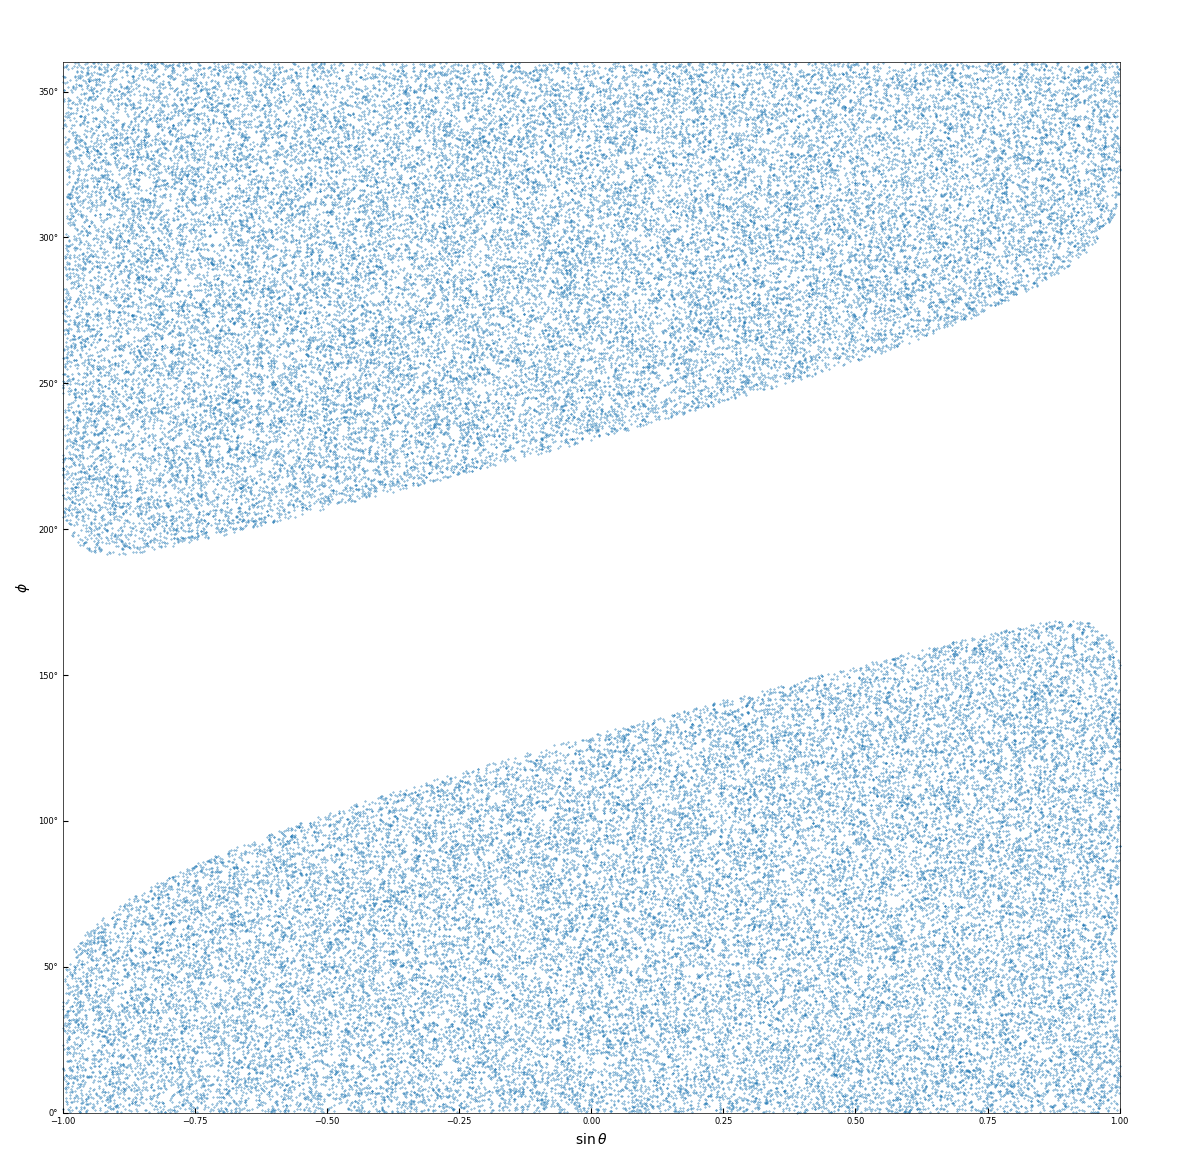

In [227]:
# cylindrical target
fig, ax = plt.subplots(1, figsize = (15, 15))
ax.tick_params(axis = 'x', direction = 'in', bottom = True, top = False, labelsize = 6)
ax.tick_params(axis = 'y', direction = 'in', left = True, right = False, labelsize = 6)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}°"))
ax.spines['left'].set_position(('data', -1))
ax.spines['left'].set_bounds((0, 360))
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_bounds((-1, 1))
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['right'].set_position(('data', 1))
ax.spines['right'].set_bounds((0, 360))
ax.spines['right'].set_linewidth(0.5)
ax.spines['top'].set_position(('data', 360))
ax.spines['top'].set_bounds((-1, 1))
ax.spines['top'].set_linewidth(0.5)
phase_target = np.loadtxt('data2mc/phase.csv', delimiter = ',')
ax.scatter(phase_target[:, 0], phase_target[:, 1], s = 0.1)
ax.set_xlabel(r"$\sin\theta$")
ax.set_ylabel(r"$\phi$")
plt.show()

# Magnification

In [223]:
# source
# fig, ax = plt.subplots(1, figsize = (10, 20))
# ax.tick_params(axis = 'x', direction = 'in', bottom = True, top = False, labelsize = 6)
# ax.tick_params(axis = 'y', direction = 'in', left = True, right = False, labelsize = 6)
# ax.spines['left'].set_position(('data', -1))
# ax.spines['left'].set_bounds((-w, w))
# ax.spines['left'].set_linewidth(0.5)
# ax.spines['bottom'].set_position(('data', -w))
# ax.spines['bottom'].set_bounds((-1, 1))
# ax.spines['bottom'].set_linewidth(0.5)
# ax.spines['right'].set_position(('data', 1))
# ax.spines['right'].set_bounds((-w, w))
# ax.spines['right'].set_linewidth(0.5)
# ax.spines['top'].set_position(('data', w))
# ax.spines['top'].set_bounds((-1, 1))
# ax.spines['top'].set_linewidth(0.5)
# ax.scatter(phase_target[:, 2], phase_target[:, 3] / hl, s = 0.1)
# ax.set_xlabel(r"$\sin\theta$")
# ax.set_ylabel(r"$y$")
# ax.axis('equal')
# ax.set_xlim(-1, 1)
# ax.set_ylim(-2, 2)
# plt.show()

In [224]:
# target
# fig, ax = plt.subplots(1, figsize = (10, 20))
# ax.tick_params(axis = 'x', direction = 'in', bottom = True, top = False, labelsize = 6)
# ax.tick_params(axis = 'y', direction = 'in', left = True, right = False, labelsize = 6)
# ax.spines['left'].set_position(('data', -1))
# ax.spines['left'].set_bounds((-w, w))
# ax.spines['left'].set_linewidth(0.5)
# ax.spines['bottom'].set_position(('data', -w))
# ax.spines['bottom'].set_bounds((-1, 1))
# ax.spines['bottom'].set_linewidth(0.5)
# ax.spines['right'].set_position(('data', 1))
# ax.spines['right'].set_bounds((-w, w))
# ax.spines['right'].set_linewidth(0.5)
# ax.spines['top'].set_position(('data', w))
# ax.spines['top'].set_bounds((-1, 1))
# ax.spines['top'].set_linewidth(0.5)
# ax.scatter(phase_target[:, 0], phase_target[:, 1] / hl, s = 0.1)
# ax.set_xlabel(r"$\sin\theta$")
# ax.set_ylabel(r"$y$")
# ax.axis('equal')
# ax.set_xlim(-1, 1)
# ax.set_ylim(-2, 2)
# plt.show()